# Description of the data in Reaxys and ChEMBL (Supplementary Figure 1, Figure 1a-c)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
chembl_bin_data = pd.read_csv('../../data/figures_source_data/chembl_compound_species_activity_datapoints.csv')
chembl_bin_data.head(1)

,smiles,active,species
0,COc1cc2c(cc1OC)C[N+](Cc1cn(-c3ccc(C(C)(C)C)cc3...,0,acinetobacterbaylyi


In [2]:
np.unique(chembl_bin_data['active'])

array([0, 1])

In [3]:
n_pairs_chembl = chembl_bin_data[["smiles", "species"]].drop_duplicates().shape[0]
n_species_chembl = chembl_bin_data["species"].nunique()
n_smiles_chembl = chembl_bin_data["smiles"].nunique()
print(f"pairs: {n_pairs_chembl}")
print(f"Unique species: {n_species_chembl}")
print(f"Unique smiles: {n_smiles_chembl}")

pairs: 427073
Unique species: 273
Unique smiles: 186462


In [4]:
df_active = chembl_bin_data[chembl_bin_data["active"] == 1]
n_pairs_active_chembl = df_active[["smiles", "species"]].drop_duplicates().shape[0]
n_species_active_chembl = df_active["species"].nunique()
n_smiles_active_chembl = df_active["smiles"].nunique()
print(f"Active pairs: {n_pairs_active_chembl}")
print(f"Unique species: {n_species_active_chembl}")
print(f"Unique smiles: {n_smiles_active_chembl}")


Active pairs: 107774
Unique species: 273
Unique smiles: 46066


In [5]:
species_per_compound = (
    df_active
    .drop_duplicates(["smiles", "species"])
    .groupby("smiles")["species"]
    .nunique()
)
compounds_per_species = (
    df_active
    .drop_duplicates(["smiles", "species"])
    .groupby("species")["smiles"]
    .nunique()
)


In [6]:
top10_species = compounds_per_species.sort_values(ascending=False).head(10)

In [7]:
species_per_compound.min(), species_per_compound.max()

(np.int64(1), np.int64(132))

In [8]:
species_per_compound.median()

np.float64(1.0)

In [9]:
compounds_per_species.min(), compounds_per_species.max(), compounds_per_species.median()

(np.int64(1), np.int64(21013), np.float64(19.0))

In [10]:
sum(species_per_compound>=10)/len(species_per_compound)*100

1.651977597360309

In [11]:
sum(compounds_per_species>=500)

24

In [ ]:
import h5py 

In [ ]:
# rx_preprocessed_file_path =  path to the preprocessed HDF5 file containing the binary activity matrix 'A', the smiles and the species names
with h5py.File(<rx_preprocessed_file_path>) as hf:
    print(hf.keys())
    A = hf['A'][:]
    smiles_rx = hf['smiles'][:]
    species_rx = hf['species'][:]
    n_smiles_rx = len(np.unique(hf['smiles']))
    n_species_rx = len(np.unique(hf['species']))
    ecfp4_rx = hf['C'][:]

<KeysViewHDF5 ['A', 'C', 'S', 'smiles', 'species']>


In [14]:
species_rx = np.array([sp.decode('utf-8') for sp in species_rx])

In [15]:
A.shape

(93781, 843)

In [16]:
compounds_per_species_rx = A.sum(axis=0)
species_per_compound_rx = A.sum(axis=1)
len(species_per_compound_rx), len(compounds_per_species_rx)

(93781, 843)

In [17]:
sum(compounds_per_species_rx>=500)

np.int64(34)

In [18]:
sum(species_per_compound_rx>=10)/len(species_per_compound_rx)*100

np.float64(1.0993698083833612)

In [19]:
index_top10 = top10_idx = np.argsort(compounds_per_species_rx)[-10:][::-1]
top10_species_rx = species_rx[index_top10]
top10_species, top10_species_rx

(species
 staphylococcusaureus         21013
 mycobacteriumtuberculosis    15462
 escherichiacoli              11223
 streptococcuspneumoniae       6453
 pseudomonasaeruginosa         5455
 enterococcusfaecalis          5314
 staphylococcusepidermidis     4452
 streptococcuspyogenes         4261
 bacillussubtilis              3882
 klebsiellapneumoniae          3878
 Name: smiles, dtype: int64,
 array(['Staphylococcus aureus', 'Escherichia coli',
        'Mycobacterium tuberculosis', 'Pseudomonas aeruginosa',
        'Klebsiella pneumoniae', 'Acinetobacter baumannii',
        'Streptococcus pneumoniae', 'Enterococcus faecalis',
        'Bacillus subtilis', 'Staphylococcus epidermidis'], dtype='<U44'))

In [20]:
counts_top10_rx = compounds_per_species_rx[index_top10]

In [21]:
names_beautiful_top_10_chembl = {
    'staphylococcusaureus':'S. aureus',
    'mycobacteriumtuberculosis': 'M. tuberculosis',
    'pseudomonasaeruginosa': 'P. aeruginosa',
    'klebsiellapneumoniae': 'K. pneumoniae',
    'enterococcusfaecalis': 'E. faecalis',
    'escherichiacoli': 'E. coli',
    'streptococcuspneumoniae': 'S. pneumoniae',
    'streptococcuspyogenes': 'S. pyogenes',
    'bacillussubtilis': 'B. subtilis',
    'staphylococcusepidermidis': 'S. epidermidis'
}

## Supplementary figure 1 (Figure A.4.1)

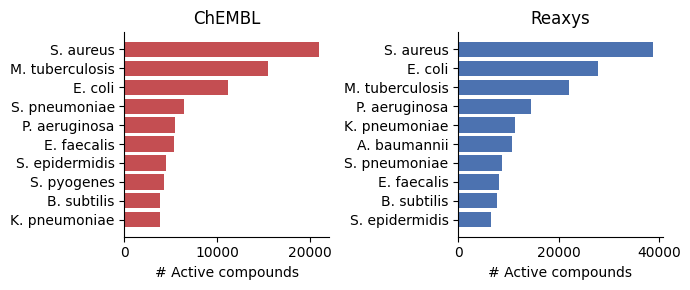

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, [ax1,ax2] = plt.subplots(1,2,figsize=(7, 3)) 

y = np.arange(len(top10_species))
# 3. Plotting
# ChEMBL top 10
rects1 = ax1.barh(y, top10_species.values, color='#C44E52')
rects2 = ax2.barh(y, counts_top10_rx, color='#4C72B0')
# ChEMBL Active (Solid red bars)
# rects2 = ax.barh(y, chembl_active, width, label='Active', color=c_rx)

# 4. Adding labels with conditional placement
def add_labels(rects, inside=True):
    for rect in rects:
        val = rect.get_width()
        ax = rect.axes
        if inside:
            # Inside the bar: text color is white for contrast, horizontal alignment is right
            ax.annotate(f'{int(val):,}',
                        xy=(val, rect.get_y() + rect.get_height() / 2),
                        xytext=(-3, 0),  
                        textcoords="offset points",
                        ha='right', va='center', fontsize=8, color='white')
        else:
            # Outside the bar (for white bars): text color is black, alignment is left
            ax.annotate(f'{int(val):,}',
                        xy=(val, rect.get_y() + rect.get_height() / 2),
                        xytext=(3, 0), 
                        textcoords="offset points",
                        ha='left', va='center', fontsize=8, color='black')

# add_labels(rects1, inside=False) # Labels for white bars go outside
# add_labels(rects2, inside=True)  # Labels for solid red go inside

# 5. Aesthetics
top10_species_short_chembl = [names_beautiful_top_10_chembl.get(x, x) for x in top10_species.index]
ax1.set_yticks(y)
ax1.set_yticklabels(top10_species_short_chembl)
# ax.set_yticklabels(groups)
ax1.invert_yaxis()  
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlabel('# Active compounds')

top10_species_rx_short = [x.split(' ')[0][0]+'. '+x.split(' ')[1] for x in top10_species_rx]
ax2.set_yticks(y)
ax2.set_yticklabels(top10_species_rx_short)
# ax.set_yticklabels(groups)
ax2.invert_yaxis()  
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlabel('# Active compounds')

ax1.set_title('ChEMBL')
ax2.set_title('Reaxys')
plt.tight_layout()

plt.show()

In [ ]:
smiles_chembl = chembl_bin_data[chembl_bin_data['active']==1]['smiles'].unique()
len(smiles_chembl)

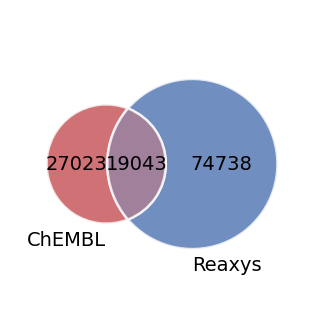

In [ ]:
# Overlap
from matplotlib_venn import venn2

fig, ax = plt.subplots(figsize=(4, 4))

v = venn2(
    [set(smiles_chembl), set(smiles_rx)],
    set_labels=("ChEMBL", "Reaxys"),
    ax=ax
)

# Make circles visually smaller
ax.set_xlim(-0.9, 0.9)
ax.set_ylim(-0.9, 0.9)

# Colors
left_color = "#C44E52"
right_color = "#4C72B0"
inter_color = "#886081"

region_colors = {
    "10": left_color,
    "01": right_color,
    "11": inter_color
}

# Style patches
for region, color in region_colors.items():
    patch = v.get_patch_by_id(region)

    if patch:
        patch.set_color(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor("white")
        patch.set_linewidth(1.8)

# Style set labels
for text in v.set_labels:
    if text:
        text.set_fontsize(14)
        # text.set_fontweight("bold")

# Style subset labels
for text in v.subset_labels:
    if text:
        text.set_fontsize(14)
        # text.set_fontweight("bold")
        text.set_color("black")

# Title
# ax.set_title(
#     'Overlap of approaches',
#     fontsize=14,
#     fontweight="bold",
#     pad=10
# )

ax.set_axis_off()


## Figure 1 b (Figure 3.4.1 b)

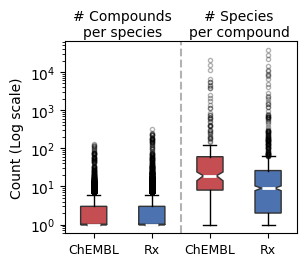

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup Data for Seaborn (Long-format is best for grouping)
data_labels = [
    'ChEMBL', 'Rx', 
    'ChEMBL', 'Rx'
]
data_list = [species_per_compound, species_per_compound_rx, 
             compounds_per_species, compounds_per_species_rx]

# 2. Styling settings
colors = ["#C44E52", "#4C72B0"] * 2 # Red for ChEMBL, Blue for RX

fig, ax = plt.subplots(figsize=(3, 2.5)) # Adjusted height for a single plot row

# 3. Create the Boxplot
# notch=True adds a confidence interval, patch_artist fills with color
bp = ax.boxplot(data_list, patch_artist=True, notch=True, 
                medianprops={'color': 'white', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})

# 4. Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('#333333')

# 5. Grouping & Aesthetics
ax.set_yscale("log")
ax.set_xticklabels(data_labels, fontsize=9)
ax.set_ylabel("Count (Log scale)")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Add a vertical divider to visually group "Compound boxes" vs "Species boxes"
ax.axvline(x=2.5, color='black', linestyle='--', alpha=0.3)
ax.text(1.5, ax.get_ylim()[1]+20000, '# Compounds\nper species', ha='center')
ax.text(3.5, ax.get_ylim()[1]+20000, '# Species\nper compound', ha='center')

plt.show()

## Figure 1 a (Figure 3.4.1 a)

In [27]:
n_active_pairs_rx = A.sum().sum()
print(f"Active pairs: {n_active_pairs_rx}")
print(f"Unique species: {n_species_rx}")
print(f"Unique smiles: {n_smiles_rx}")

Active pairs: 211763
Unique species: 843
Unique smiles: 93781


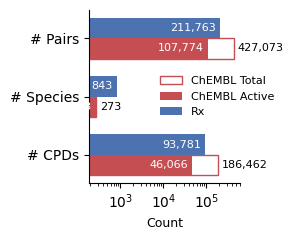

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Organize your data (Ensure these are defined in your environment)
groups = ['# Pairs', '# Species', '# CPDs']
chembl_totals = [n_pairs_chembl, n_species_chembl, n_smiles_chembl]
chembl_active = [n_pairs_active_chembl, n_species_active_chembl, n_smiles_active_chembl]
rx_totals     = [n_active_pairs_rx, n_species_rx, n_smiles_rx]

# 2. Setup Y positions
y = np.arange(len(groups))
width = 0.35 

fig, ax = plt.subplots(figsize=(3, 2.5)) 

# Colors
c_chembl = '#C44E52'
c_rx     = '#4C72B0'

# 3. Plotting
# ChEMBL Total (White bars)
rects1 = ax.barh(y + width/2, chembl_totals, width, label='ChEMBL Total', color='white', edgecolor=c_chembl)
# ChEMBL Active (Solid red bars)
rects2 = ax.barh(y + width/2, chembl_active, width, label='ChEMBL Active', color=c_chembl)
# RX (Solid blue bars)
rects3 = ax.barh(y - width/2, rx_totals, width, label='Rx', color=c_rx)

# 4. Adding labels with conditional placement
def add_labels(rects, inside=True):
    for rect in rects:
        val = rect.get_width()
        
        if inside:
            # Inside the bar: text color is white for contrast, horizontal alignment is right
            ax.annotate(f'{int(val):,}',
                        xy=(val, rect.get_y() + rect.get_height() / 2),
                        xytext=(-3, 0),  
                        textcoords="offset points",
                        ha='right', va='center', fontsize=8, color='white')
        else:
            # Outside the bar (for white bars): text color is black, alignment is left
            ax.annotate(f'{int(val):,}',
                        xy=(val, rect.get_y() + rect.get_height() / 2),
                        xytext=(3, 0), 
                        textcoords="offset points",
                        ha='left', va='center', fontsize=8, color='black')

add_labels(rects1, inside=False) # Labels for white bars go outside
add_labels(rects2, inside=True)  # Labels for solid red go inside
add_labels(rects3, inside=True)  # Labels for solid blue go inside

# 5. Aesthetics
ax.set_yticks(y)
ax.set_yticklabels(groups)
ax.invert_yaxis()  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Count', fontsize=9)

# Legend shifted further right to avoid collision with middle labels
ax.legend(loc='center left', bbox_to_anchor=(0.4, 0.5), frameon=False, fontsize=8)

ax.set_xscale('log')
plt.tight_layout()

plt.show()

## Figure 1 c (Figure 3.4.1 c)

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
def get_ecfp4(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    else:
        return None

In [ ]:
ecfp4_chembl = [get_ecfp4(s) for s in smiles_chembl]
mask_none = [True if ecfp4_chembl[i] is not None else False for i in range(len(ecfp4_chembl))]
ecfp4_chembl = np.array(ecfp4_chembl)[mask_none]

In [ ]:
ecfp4_all = np.vstack([ecfp4_chembl, ecfp4_rx])

In [ ]:
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2,  random_state=354, init='pca').fit_transform(ecfp4_all)

In [ ]:
labels = ['ChEMBL']*len(ecfp4_chembl) + ['Rx']*len(ecfp4_rx)

In [ ]:
import numpy as np
from scipy.interpolate import interpn
import matplotlib.pyplot as plt

def get_density_and_size(x, y, min_size=5, max_size=10):
    """
    Calculates point density using a 2D histogram and interpolates it 
    to map density values to marker sizes.
    """
    if len(x) == 0: 
        return np.array([]), []
    
    # 1. Compute the 2D histogram density
    # Bins can be adjusted (10-20 is usually a good range for t-SNE)
    data, x_e, y_e = np.histogram2d(x, y, bins=10, density=True)
    
    # 2. Find the centers of the bins for interpolation
    # The 0.65 factor matches your previous implementation for smoothing
    x_centers = 0.65 * (x_e[1:] + x_e[:-1])
    y_centers = 0.65 * (y_e[1:] + y_e[:-1])
    
    # 3. Interpolate the density values for each specific (x, y) point
    z = interpn(
        (x_centers, y_centers),
        data,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False,
        fill_value=0.0
    )
    
    # Clean up any potential NaNs from the interpolation
    z[np.isnan(z)] = 0.0
    
    # 4. Normalize Z to a [0, 1] range to scale the marker sizes
    z_min, z_max = z.min(), z.max()
    if z_max - z_min > 1e-9:
        z_norm = (z - z_min) / (z_max - z_min)
    else:
        z_norm = np.zeros_like(z)
        
    # Map the normalized density to the requested size range
    sizes = min_size + z_norm * (max_size - min_size)
    
    return z, sizes

# Helper function for density calculation to keep the loop clean
def get_density_and_size(x, y, min_size=5, max_size=10):
    if len(x) == 0: return np.array([]), []
    data, x_e, y_e = np.histogram2d(x, y, bins=10, density=True)
    z = interpn(
        (0.65 * (x_e[1:] + x_e[:-1]), 0.65 * (y_e[1:] + y_e[:-1])),
        data,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False,
    )
    z[np.isnan(z)] = 0.0
    # Normalize Z for sizing
    z_norm = (z - z.min()) / (z.max() - z.min() + 1e-9)
    sizes = min_size + z_norm * (max_size - min_size)
    return z, sizes

Processing group: Rx
Processing group: ChEMBL


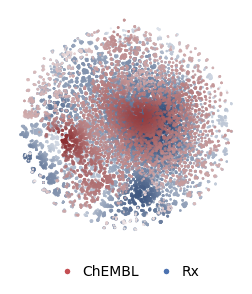

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.lines import Line2D

# 1. Wider colormaps: Starting from a very light 5% tint to the full color
# Original ChEMBL #C44E52 -> Darkened to #8B2E31
# Original Rx #4C72B0 -> Darkened to #2D4875
cmap_chembl = mcolors.LinearSegmentedColormap.from_list('chembl', ['#fcfcfc', '#8B2E31'])
cmap_rx = mcolors.LinearSegmentedColormap.from_list('rx', ['#f2f5f9', '#2D4875'])
fig, ax = plt.subplots(figsize=(3, 3))

# Group configuration
group_configs = [
    {'name': 'Rx',     'color': '#4C72B0', 'cmap': cmap_rx,     'is_chembl': False},
    {'name': 'ChEMBL', 'color': '#C44E52', 'cmap': cmap_chembl, 'is_chembl': True}
    
]

percenetage_to_plot = 0.15
for g in group_configs:
    print(f"Processing group: {g['name']}")
    # Filter and Subsample 10K
    mask = (np.array(labels) == 'ChEMBL') if g['is_chembl'] else (np.array(labels) != 'ChEMBL')
    indices = np.where(mask)[0]
    
    if len(indices) > n_samples:
        n_samples = int(len(indices) * percenetage_to_plot)
        indices = np.random.choice(indices, n_samples, replace=False)
    
    xb, yb = X_tsne[indices, 0], X_tsne[indices, 1]
    
    # Density and sizing
    z_b, s_b = get_density_and_size(xb, yb, min_size=2, max_size=5)
    idx_b = z_b.argsort()
    
    # Plot
    ax.scatter(xb[idx_b], yb[idx_b], cmap=g['cmap'], c=s_b[idx_b], s=s_b[idx_b], alpha=0.7, lw=0)

# 2. Remove axis
ax.set_axis_off()

# 3. Custom Legend at the bottom, center, no frame, no alpha
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ChEMBL', 
           markerfacecolor='#C44E52', markersize=5),
    Line2D([0], [0], marker='o', color='w', label='Rx', 
           markerfacecolor='#4C72B0', markersize=5)
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05),
          ncol=2, frameon=False, handletextpad=0.1, columnspacing=1.0)

plt.show()

## Supplementary figure 4 (Figure A.4.4)

In [73]:
chembl_bin_data = pd.read_csv('../../data/figures_source_data/chembl_compound_species_activity_datapoints.csv')
chembl_bin_data.head(1)

,smiles,active,species
0,COc1cc2c(cc1OC)C[N+](Cc1cn(-c3ccc(C(C)(C)C)cc3...,0,acinetobacterbaylyi


In [74]:
df = (
    chembl_bin_data
    .groupby("species")
    .agg(
        total_molecules=("smiles", "count"),
        active_molecules=("active", "sum")
    )
    .reset_index()
)

df["ratio"] = df["active_molecules"] / df["total_molecules"]

In [75]:
target_species = [
    "pseudomonasaeruginosa", "acinetobacterbaumannii", "enterococcusfaecalis",
    "klebsiellapneumoniae", "escherichiacoli", "staphylococcusaureus"
]
spceis2name = {
    "pseudomonasaeruginosa": "P. aeruginosa",
"acinetobacterbaumannii": "A. baumannii", "enterococcusfaecalis": "E. faecalis", "klebsiellapneumoniae": "K. pneumoniae", "escherichiacoli": "E. coli", "staphylococcusaureus": "S. aureus" }

In [76]:
df

,species,total_molecules,active_molecules,ratio
0,acinetobacterbaumannii,28298,1121,0.039614
1,acinetobacterbaylyi,3,2,0.666667
2,acinetobactercalcoaceticus,365,149,0.408219
3,acinetobactercalcoaceticussubsp.anitratus,18,3,0.166667
4,acinetobacterhaemolyticus,21,8,0.380952
...,...,...,...,...
268,xanthomonasoryzae,49,10,0.204082
269,xanthomonasvesicatoria,33,3,0.090909
270,yersiniaenterocolitica,34,15,0.441176
271,yersiniapestis,136,43,0.316176


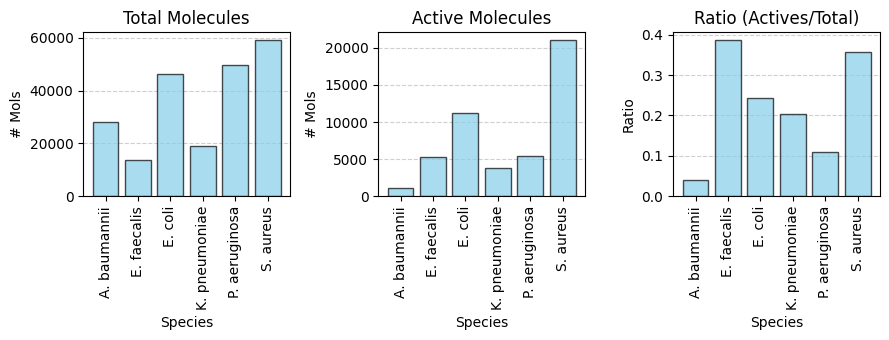

In [78]:
# Setting up the figure
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(9, 3.5))
axes = [ax1, ax2, ax3]

columns = ['total_molecules', 'active_molecules', 'ratio']
titles = ['Total Molecules', 'Active Molecules', 'Ratio (Actives/Total)']
for ax, col, title in zip(axes, columns, titles):
    data = df[[col,'species']]
    data = data[df['species'].isin(target_species)]
    species = data['species'].values 
    species = [spceis2name[s] for s in species]
    data = data[col].values
    x = np.arange(len(data))
    ax.bar(x,data, color='skyblue', edgecolor='black', alpha=0.7, zorder=2)
    
    # The Magic Trick: Set the scale to log10
    ax.set_title(title)
    ax.set_xlabel('Species')
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
    ax.set_ylabel('# Mols')
    ax.set_xticks(x, labels=species, rotation=90)
ax3.set_ylabel('Ratio')
plt.tight_layout()
plt.show()

# Bacterial descriptors

## Figure 1 e (Figure 3.4.1 e)

In [ ]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import pearsonr, spearmanr
import umap.umap_ as umap 
from collections import Counter
import re
from matplotlib.lines import Line2D
import pickle
from sklearn.metrics import roc_curve, auc

In [32]:
with h5py.File('../../data/bacteria_embeddings.h5', 'r') as f:
    embeddings = f['embeddings'][:]
    species = f['species'][:]
    species = [s.decode('utf8') for s in species]
species = np.array(species)

In [33]:
embeddings.shape

(843, 3072)

In [ ]:
# --- UMAP Projection ---
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(embeddings)

In [ ]:
# 1. Find the top 10 most frequent labels
genus = [s.split(' ')[0] for s in species]
label_counts = Counter(genus)
# We use a list here instead of a set to maintain order
top_labels_unsorted = [label for label, _ in label_counts.most_common(10)]

# 2. SORT the top labels alphabetically
top_labels_sorted = sorted(top_labels_unsorted)

# 3. Assign colors based on the alphabetical list
palette = sns.color_palette("Paired", n_colors=10)
label_colors = {label: color for label, color in zip(top_labels_sorted, palette)}

# 4. Handle the "Other" labels
label_colors.update({label: 'gray' for label in label_counts if label not in label_colors})

# 5. Map colors for plotting
point_colors = [label_colors[label] for label in genus]

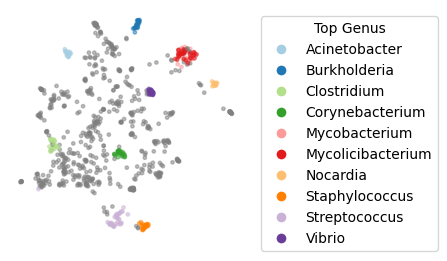

In [ ]:
# Plot UMAP
fig, ax = plt.subplots(figsize=(3, 3))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=point_colors, alpha=0.5, s=6)

# plt.title('UMAP')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=label)
                    for label, color in label_colors.items() if color != 'gray'], title="Top Genus",
                    bbox_to_anchor=(1.05, 1))
ax.set_axis_off()
plt.show()

## Figure 1 f (Figure 3.4.1 f)

In [36]:
#### Text distances
dist_text = squareform(pdist(embeddings, metric='cosine'))
dist_text = pd.DataFrame(dist_text, index=species, columns=species)

In [61]:
######## Taxonomic distances ##########
dists_mat = pd.read_csv('../../data/figures_source_data/taxonomic_distances.csv')
dists_mat.head(2)

,Unnamed: 0,46125,119206,1376,1377,46124,1652,2748,29394,1602,...,173,83560,813,83558,57497,274,850,856,859,851
0,46125,0,3,3,3,2,4,4,4,4,...,7,8,8,7,7,7,8,8,7,7
1,119206,3,0,2,2,3,5,5,5,5,...,8,9,9,8,8,8,9,9,8,8


In [55]:
# Map tax IDs back to species names
with open('../../data/bacterial_names2ncbi_ID.p', 'rb') as f:
    name2taxid = pickle.load(f)
taxid2name = {v:k for k,v in name2taxid.items()}

In [56]:
dists_mat.columns=['species']+[taxid2name[str(s)] for s in dists_mat.columns[1:]]

In [57]:
dists_mat['species'] = [taxid2name[str(s)] for s in dists_mat['species']]

In [58]:
def normalize_name(name):
    # Remove square brackets and normalize whitespace
    return re.sub(r'\s+', ' ', re.sub(r'[\[\]]', '', name.strip()))

dists_mat.species = dists_mat.species.map(normalize_name)
bacterial_names = dists_mat.species
len(bacterial_names)

822

In [59]:
dists_mat = dists_mat.set_index("species")
dists_taxo = dists_mat.iloc[:]

In [60]:
dists_taxo

,Abiotrophia defectiva,Aerococcus sanguinicola,Aerococcus urinae,Aerococcus viridans,Granulicatella adiacens,Alloiococcus otitis,Carnobacterium divergens,Dolosigranulum pigrum,Companilactobacillus alimentarius,Lacticaseibacillus casei,...,Leptospira interrogans,Chlamydia muridarum,Chlamydia trachomatis,Chlamydia pneumoniae,Deinococcus radiopugnans,Thermus thermophilus,Fusobacterium mortiferum,Fusobacterium varium,Fusobacterium necrophorum,Fusobacterium nucleatum
species,,,,,,,,,,,,,,,,,,,,,
Abiotrophia defectiva,0,3,3,3,2,4,4,4,4,5,...,7,8,8,7,7,7,8,8,7,7
Aerococcus sanguinicola,3,0,2,2,3,5,5,5,5,6,...,8,9,9,8,8,8,9,9,8,8
Aerococcus urinae,3,2,0,2,3,5,5,5,5,6,...,8,9,9,8,8,8,9,9,8,8
Aerococcus viridans,3,2,2,0,3,5,5,5,5,6,...,8,9,9,8,8,8,9,9,8,8
Granulicatella adiacens,2,3,3,3,0,4,4,4,4,5,...,7,8,8,7,7,7,8,8,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Thermus thermophilus,7,8,8,8,7,7,7,7,7,8,...,4,5,5,4,2,0,5,5,4,4
Fusobacterium mortiferum,8,9,9,9,8,8,8,8,8,9,...,5,6,6,5,5,5,0,2,3,3
Fusobacterium varium,8,9,9,9,8,8,8,8,8,9,...,5,6,6,5,5,5,2,0,3,3


In [62]:
## Phylo distances
phylo_data = pd.read_csv('../../data/figures_source_data/phylogenetic_distances.csv')
phylo_data.head(2)

,Unnamed: 0,Abiotrophia_defectiva,Acetobacter_aceti,Achromobacter_denitrificans,Achromobacter_ruhlandii,Achromobacter_xylosoxidans,Acidipropionibacterium_acidipropionici,Acidovorax_temperans,Acinetobacter_baumannii,Acinetobacter_baylyi,...,Xanthomonas_vesicatoria,Xylella_fastidiosa,Yersinia_bercovieri,Yersinia_enterocolitica,Yersinia_intermedia,Yersinia_mollaretii,Yersinia_pestis,Yersinia_pseudotuberculosis,Yersinia_ruckeri,Zymomonas_mobilis
0,Abiotrophia_defectiva,0.00000,3194.17114,3194.17114,3194.17114,3194.17114,2937.30100,3194.17114,3194.17114,3194.17114,...,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114
1,Acetobacter_aceti,3194.17114,0.00000,2328.26642,2328.26642,2328.26642,3194.17114,2328.26642,2328.26642,2328.26642,...,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,1710.49761


In [63]:
phylo_data.index = [x.replace('_', ' ') for x in phylo_data['Unnamed: 0'].values]
phylo_data.drop(columns=['Unnamed: 0'], inplace=True)
phylo_data.columns = [x.replace('_', ' ') for x in phylo_data.columns]
phylo_data

,Abiotrophia defectiva,Acetobacter aceti,Achromobacter denitrificans,Achromobacter ruhlandii,Achromobacter xylosoxidans,Acidipropionibacterium acidipropionici,Acidovorax temperans,Acinetobacter baumannii,Acinetobacter baylyi,Acinetobacter beijerinckii,...,Xanthomonas vesicatoria,Xylella fastidiosa,Yersinia bercovieri,Yersinia enterocolitica,Yersinia intermedia,Yersinia mollaretii,Yersinia pestis,Yersinia pseudotuberculosis,Yersinia ruckeri,Zymomonas mobilis
Abiotrophia defectiva,0.00000,3194.17114,3194.17114,3194.17114,3194.17114,2937.30100,3194.17114,3194.17114,3194.17114,3194.17114,...,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114,3194.17114
Acetobacter aceti,3194.17114,0.00000,2328.26642,2328.26642,2328.26642,3194.17114,2328.26642,2328.26642,2328.26642,2328.26642,...,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,2328.26642,1710.49761
Achromobacter denitrificans,3194.17114,2328.26642,0.00000,0.62834,21.81254,3194.17114,872.13000,1992.88500,1992.88500,1992.88500,...,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,2328.26642
Achromobacter ruhlandii,3194.17114,2328.26642,0.62834,0.00000,21.81254,3194.17114,872.13000,1992.88500,1992.88500,1992.88500,...,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,2328.26642
Achromobacter xylosoxidans,3194.17114,2328.26642,21.81254,21.81254,0.00000,3194.17114,872.13000,1992.88500,1992.88500,1992.88500,...,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,1992.88500,2328.26642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yersinia mollaretii,3194.17114,2328.26642,1992.88500,1992.88500,1992.88500,3194.17114,1992.88500,1481.02000,1481.02000,1481.02000,...,1777.88500,1777.88500,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2328.26642
Yersinia pestis,3194.17114,2328.26642,1992.88500,1992.88500,1992.88500,3194.17114,1992.88500,1481.02000,1481.02000,1481.02000,...,1777.88500,1777.88500,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2328.26642
Yersinia pseudotuberculosis,3194.17114,2328.26642,1992.88500,1992.88500,1992.88500,3194.17114,1992.88500,1481.02000,1481.02000,1481.02000,...,1777.88500,1777.88500,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2328.26642
Yersinia ruckeri,3194.17114,2328.26642,1992.88500,1992.88500,1992.88500,3194.17114,1992.88500,1481.02000,1481.02000,1481.02000,...,1777.88500,1777.88500,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2328.26642


In [ ]:
## Sensitivity according chembl
chembl_sens = pd.read_csv('../../data/figures_source_data/binary_activity_matrix_chembl.csv')

sens_descriptors = chembl_sens.drop(columns=['smiles']).values.T

## sensitivity distances
dists_chem = squareform(pdist(sens_descriptors, metric='jaccard'))
dists_chem = pd.DataFrame(dists_chem, index=chembl_sens.columns[1:], columns=chembl_sens.columns[1:])
dists_chem.head(2)

,acinetobacterbaumannii,acinetobacterbaylyi,acinetobactercalcoaceticus,acinetobactercalcoaceticussubsp.anitratus,acinetobacterhaemolyticus,acinetobacterlwoffii,acinetobacterpittii,actinomycesisraelii,actinomycesnaeslundii,actinomycesviscosus,...,vibrioparahaemolyticus,vibriosplendidus,vibriovulnificus,xanthomonasaxonopodis,xanthomonascampestris,xanthomonasoryzae,xanthomonasvesicatoria,yersiniaenterocolitica,yersiniapestis,yersiniapseudotuberculosis
acinetobacterbaumannii,0.000000,0.998216,0.985623,0.998217,0.993761,0.986888,0.984848,0.994737,0.991266,0.9975,...,0.992321,0.996441,0.995563,1.0,0.998236,1.0,1.0,0.99469,0.996552,0.996564
acinetobacterbaylyi,0.998216,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,...,1.000000,1.000000,1.000000,1.0,1.000000,1.0,1.0,1.00000,1.000000,1.000000


In [ ]:
# rx_preprocessed_file_path =  path to the preprocessed HDF5 file containing the binary activity matrix 'A', the smiles and the species names
with h5py.File(<rx_preprocessed_file_path>) as hf:
    print(hf.keys())
    rx = hf['A'][:]
    species_rx = hf['species'][:]
    species_rx = np.array([s.decode('utf8') for s in species_rx])
dist_rx = squareform(pdist(rx.T, metric='jaccard'))
dist_rx = pd.DataFrame(dist_rx, index=species_rx, columns=species_rx)

<KeysViewHDF5 ['A', 'C', 'S', 'smiles', 'species']>


In [65]:
dist_rx = squareform(pdist(A.T, metric='jaccard'))
dist_rx = pd.DataFrame(dist_rx, index=species_rx, columns=species_rx)

In [66]:
dist_rx.head(2)

,Abiotrophia defectiva,Acetobacter aceti,Achromobacter denitrificans,Achromobacter ruhlandii,Achromobacter xylosoxidans,Acidipropionibacterium acidipropionici,Acidovorax temperans,Acinetobacter baumannii,Acinetobacter baylyi,Acinetobacter beijerinckii,...,Clostridium innocuum,Clostridium leptum,Clostridium nexile,Clostridium scindens,Clostridium symbiosum,Eubacterium nodatum,Eubacterium siraeum,Haemophilus ducreyi,Pasteurella aerogenes,Ruminococcus lactaris
Abiotrophia defectiva,0.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.999906,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000,1.0,1.0
Acetobacter aceti,1.0,0.0,0.888889,0.888889,0.969697,1.0,1.0,0.999906,0.933333,0.833333,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.875,1.0,1.0


In [67]:
tax_color = '#55A868'
phylo_color = '#DD8452'

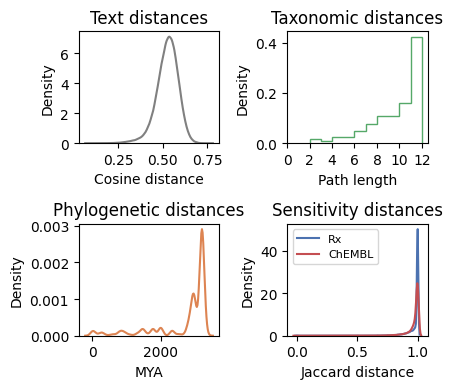

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Groups to plot
group_configs = [
    {'name': 'Text distances',     'color': 'darkgrey', 'data':dist_text, 'metric':'Cosine dist'},
    {'name': 'Taxonomic distances', 'color': tax_color, 'data':dists_taxo, 'metric':'Path length'},
    {'name': 'Phylogenetic distances', 'color': phylo_color, 'data':phylo_data, 'metric':'MYA'},
    {'name': 'Sensitivity distances', 'color': ['#C44E52','#4C72B0'],'data':[dists_chem,dist_rx], 'metric':'Jaccard dist'}
]

# 3. Create the 2x2 Plotting Grid (Independent Axes)
# sharex=False is the default, but we'll be explicit here
fig, axes = plt.subplots(2, 2, figsize=(4.5, 4))
[ax1,ax2,ax3,ax4] = axes.flatten()

dist_text_flat = dist_text.values[np.triu_indices(len(dist_text), k=1)]  # Get upper triangle without diagonal
sns.kdeplot(dist_text_flat, ax=ax1, color='gray')
ax1.set_title('Text distances')
ax1.set_xlabel('Cosine distance')

dists_taxo_flat = dists_taxo.values[np.triu_indices(len(dists_taxo), k=1)]  # Get upper triangle without diagonal
ax2.hist(dists_taxo_flat, density=True, histtype='step', color=tax_color)
ax2.set_title(f'Taxonomic distances')
ax2.set_xlabel('Path length')
ax2.set_xticks(np.arange(0, 13, 2))
ax2.set_ylabel('Density')

phylo_data_flat = phylo_data.values[np.triu_indices(len(phylo_data), k=1)]  # Get upper triangle without diagonal
sns.kdeplot(phylo_data_flat, ax=ax3, color=phylo_color)
ax3.set_title('Phylogenetic distances')
ax3.set_xlabel('MYA')

dist_rx_flat = dist_rx.values[np.triu_indices(len(dist_rx), k=1)]  # Get upper triangle without diagonal
dists_chem_flat = dists_chem.values[np.triu_indices(len(dists_chem), k=1)]  # Get upper triangle without diagonal
sns.kdeplot(dist_rx_flat, ax=ax4, label='Rx', color='#4C72B0')
sns.kdeplot(dists_chem_flat, ax=ax4, label='ChEMBL', color='#C44E52')
ax4.set_title('Sensitivity distances')
ax4.set_xlabel('Jaccard distance')
ax4.legend(fontsize=8)

plt.tight_layout()

plt.show()

## Figure 1 g (Figure 3.4.1 e)

In [69]:
species_text = [s.lower().replace(' ','') for s in dist_text.columns.values]
species_taxo = [s.lower().replace(' ','') for s in dists_taxo.columns.values]
species_phylo = [s.lower().replace(' ','') for s in phylo_data.columns.values]
species_sens_chem = dists_chem.columns.values
species_sens_rx = [s.lower().replace(' ','') for s in dist_rx.columns.values]

dist_text.columns = species_text
dist_text.index = species_text
dists_taxo.columns = species_taxo
dists_taxo.index = species_taxo
phylo_data.columns = species_phylo
phylo_data.index = species_phylo
dist_rx.columns = species_sens_rx
dist_rx.index = species_sens_rx

722
722
255
722


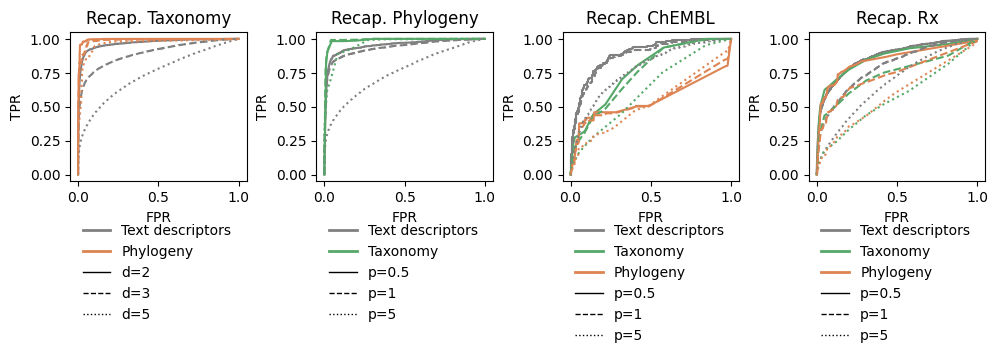

In [71]:
# Final all together
fig, ax = plt.subplots(1,4, figsize=(10, 4))
ax1, ax2, ax3, ax4 = ax

## ---- Taxonomy recap ---- ##
common_species_taxo = list(set(dists_taxo.columns) & set(dist_text.columns) & set(phylo_data.columns))
print(len(common_species_taxo))

dist_text_f = dist_text.loc[common_species_taxo, common_species_taxo]
dist_taxo_f = dists_taxo.loc[common_species_taxo, common_species_taxo]
dist_phylo_f = phylo_data.loc[common_species_taxo, common_species_taxo]

linestyles = ['-', '--', ':']
thresholds = [2, 3, 5]

# We'll store handles here to ensure we have the exact objects for the legend
text_handles = []
phylo_handles = []

for i, p in enumerate(thresholds):
    y = np.array(dist_taxo_f.values[np.triu_indices(len(dist_taxo_f), k=1)] <= p)*1
    text_y = dist_text_f.values[np.triu_indices(len(dist_text_f), k=1)]
    phylo_y = dist_phylo_f.values[np.triu_indices(len(dist_phylo_f), k=1)]
    
    fpr_text, tpr_text, _ = roc_curve(y, 1-text_y)
    fpr_phylo, tpr_phylo, _ = roc_curve(y, 1-phylo_y)
    
    roc_auc_text = auc(fpr_text, tpr_text)
    roc_auc_phylo = auc(fpr_phylo, tpr_phylo)
    
    # Plot and save handles
    line_t, = ax1.plot(fpr_text, tpr_text, color='gray', linestyle=linestyles[i],
                     label=f'd={p} (AUC={roc_auc_text:.2f})')
    line_p, = ax1.plot(fpr_phylo, tpr_phylo, color=phylo_color, linestyle=linestyles[i],
                     label=f'd={p} (AUC={roc_auc_phylo:.2f})')
    
    text_handles.append(line_t)
    phylo_handles.append(line_p)

# Create the Category Headers (using black to represent the concept, not a specific line)
style_headers = [
    Line2D([0], [0], color='gray', lw=2, label='Text desc.'),
    Line2D([0], [0], color=phylo_color, lw=2, label='Phylogeny')
]

# Combine all handles and labels
# Order: Headers first, then Text results, then Phylo results
all_handles = style_headers + text_handles + phylo_handles
all_labels = [h.get_label() for h in all_handles]

# Custom order: [Header1, Header2, Text_p2, Phylo_p2, Text_p3, Phylo_p3, Text_p5, Phylo_p5]
# This interleaves them so p-values stay together
order = [0, 1, 2, 5, 3, 6, 4, 7]

# ax1.legend(
#     [all_handles[idx] for idx in order],
#     [all_labels[idx] for idx in order],
#     bbox_to_anchor=(0, -0.2),
#     loc='upper left',
#     frameon=False
# )
# Legend for Ax1
handles1 = [
    Line2D([0], [0], color='gray', lw=2, label='Text descriptors'),
    Line2D([0], [0], color=phylo_color, lw=2, label='Phylogeny'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[0], label='d=2'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[1], label='d=3'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[2], label='d=5')
]
ax1.legend(handles=handles1, bbox_to_anchor=(0, -0.2), loc='upper left',frameon=False)

ax1.set_title('Recap. Taxonomy')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')

## ---- Phylogeny recap ---- ##
common_species_phylo = list(set(phylo_data.columns) & set(dist_text.columns) & set(dists_taxo.columns))
print(len(common_species_phylo))

dist_text_f = dist_text.loc[common_species_phylo, common_species_phylo]
dist_phylo_f = phylo_data.loc[common_species_phylo, common_species_phylo]
dist_taxo_f = dists_taxo.loc[common_species_phylo, common_species_phylo]

percentiles = [0.5, 1, 5]

# Lists to collect line handles for the custom legend
text_handles = []
taxo_handles = []

for i, p in enumerate(percentiles):
    # Calculate threshold based on phylogeny percentile
    threshold = np.percentile(phylo_data.values[np.triu_indices(len(phylo_data), k=1)], p)
    y = np.array(dist_phylo_f.values[np.triu_indices(len(dist_phylo_f), k=1)] <= threshold)*1
    
    # Get corresponding distances
    text_y = dist_text_f.values[np.triu_indices(len(dist_text_f), k=1)]
    taxo_y = dist_taxo_f.values[np.triu_indices(len(dist_taxo_f), k=1)]
    
    fpr_text, tpr_text, _ = roc_curve(y, 1-text_y)
    fpr_taxo, tpr_taxo, _ = roc_curve(y, 1-taxo_y)
    
    roc_auc_text = auc(fpr_text, tpr_text)
    roc_auc_taxo = auc(fpr_taxo, tpr_taxo)
    
    # Plot and store handles with the specific linestyle
    line_t, = ax2.plot(fpr_text, tpr_text, color='gray', linestyle=linestyles[i],
                     label=f'p={p} (AUC={roc_auc_text:.2f})')
    line_x, = ax2.plot(fpr_taxo, tpr_taxo, color=tax_color, linestyle=linestyles[i],
                     label=f'p={p} (AUC={roc_auc_taxo:.2f})')
    
    text_handles.append(line_t)
    taxo_handles.append(line_x)

# Setting up labels and titles
ax2.set_title('Recap. Phylogeny')
ax2.set_xlabel('FPR')
ax2.set_ylabel('TPR')

# --- Legend Logic ---

# Create Header handles for the color key
style_headers = [
    Line2D([0], [0], color='gray', lw=2, label='Text descriptors'),
    Line2D([0], [0], color=tax_color, lw=2, label='Taxonomy')
]

# Combine all handles and labels
all_handles = np.array(style_headers + text_handles + taxo_handles)
all_labels = np.array([h.get_label() for h in all_handles])

# Order: [Text Header, Taxo Header, Text p=0.5, Taxo p=0.5, Text p=1, Taxo p=1, Text p=5, Taxo p=5]
order = [0, 1, 2, 5, 3, 6, 4, 7]

# ax2.legend(
#     all_handles[order],
#     all_labels[order],
#     bbox_to_anchor=(0, -0.2),
#     loc='upper left',
#     frameon=False
# )
# Legend for Ax2
handles2 = [
    Line2D([0], [0], color='gray', lw=2, label='Text descriptors'),
    Line2D([0], [0], color=tax_color, lw=2, label='Taxonomy'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[0], label='p=0.5'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[1], label='p=1'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[2], label='p=5')
]
ax2.legend(handles=handles2, bbox_to_anchor=(0, -0.2), loc='upper left',frameon=False)

## ---- Sensitivity recap (ChEMBL) ---- ##
common_species_sens_chem = list(set(dists_chem.columns) & set(dist_text.columns) & set(dists_taxo.columns) & set(phylo_data.columns))
print(len(common_species_sens_chem))

dist_text_f = dist_text.loc[common_species_sens_chem, common_species_sens_chem]
dist_chem_f = dists_chem.loc[common_species_sens_chem, common_species_sens_chem]
dist_phylo_f = phylo_data.loc[common_species_sens_chem, common_species_sens_chem]
dist_taxo_f = dists_taxo.loc[common_species_sens_chem, common_species_sens_chem]

percentiles = [0.5, 1, 5]

# Lists to collect line handles for the custom legend
text_handles = []
taxo_handles = []
phylo_handles = []

for i, p in enumerate(percentiles):
    # Calculate threshold based on chemical percentile
    threshold = np.percentile(dists_chem.values[np.triu_indices(len(dists_chem), k=1)], p)
    y = np.array(dist_chem_f.values[np.triu_indices(len(dist_chem_f), k=1)] <= threshold)*1
    
    # Get corresponding distances
    text_y = dist_text_f.values[np.triu_indices(len(dist_text_f), k=1)]
    taxo_y = dist_taxo_f.values[np.triu_indices(len(dist_taxo_f), k=1)]
    phylo_y = dist_phylo_f.values[np.triu_indices(len(dist_phylo_f), k=1)]
    
    fpr_text, tpr_text, _ = roc_curve(y, 1-text_y)
    fpr_taxo, tpr_taxo, _ = roc_curve(y, 1-taxo_y)
    fpr_phylo, tpr_phylo, _ = roc_curve(y, 1-phylo_y)
    
    roc_auc_text = auc(fpr_text, tpr_text)
    roc_auc_taxo = auc(fpr_taxo, tpr_taxo)
    roc_auc_phylo = auc(fpr_phylo, tpr_phylo)
    
    # Plot and store handles with the specific linestyle
    l_text, = ax3.plot(fpr_text, tpr_text, color='gray', linestyle=linestyles[i],
                     label=f'p={p} (AUC={roc_auc_text:.2f})')
    l_taxo, = ax3.plot(fpr_taxo, tpr_taxo, color=tax_color, linestyle=linestyles[i],
                     label=f'p={p} (AUC={roc_auc_taxo:.2f})')
    l_phylo, = ax3.plot(fpr_phylo, tpr_phylo, color=phylo_color, linestyle=linestyles[i],
                      label=f'p={p} (AUC={roc_auc_phylo:.2f})')
    
    text_handles.append(l_text)
    taxo_handles.append(l_taxo)
    phylo_handles.append(l_phylo)

# --- Legend Logic ---

# Create Header handles for the color key
style_headers = [
    Line2D([0], [0], color='gray', lw=2, label='Text descriptors'),
    Line2D([0], [0], color=tax_color, lw=2, label='Taxonomy'),
    Line2D([0], [0], color=phylo_color, lw=2, label='Phylogeny')
]

# Combine all handles and labels
all_handles = np.array(style_headers + text_handles + taxo_handles + phylo_handles)
all_labels = np.array([h.get_label() for h in all_handles])

# NEW ORDER (3 headers, then 3 results per p-value):
# [H_Text, H_Taxo, H_Phylo, Text_p0.5, Taxo_p0.5, Phylo_p0.5, Text_p1.0, ...]
# Index map: Headers(0,1,2), Text(3,4,5), Taxo(6,7,8), Phylo(9,10,11)
order = [0, 1, 2, 3, 6, 9, 4, 7, 10, 5, 8, 11]

# ax3.legend(
#     all_handles[order],
#     all_labels[order],
#     bbox_to_anchor=(0, -0.2),
#     loc='upper left',
#     frameon=False
# )
# Legend for Ax3
handles3 = [
    Line2D([0], [0], color='gray', lw=2, label='Text descriptors'),
    Line2D([0], [0], color=tax_color, lw=2, label='Taxonomy'),
    Line2D([0], [0], color=phylo_color, lw=2, label='Phylogeny'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[0], label='p=0.5'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[1], label='p=1'),
    Line2D([0], [0], color='black', lw=1, linestyle=linestyles[2], label='p=5')
]
ax3.legend(handles=handles3, bbox_to_anchor=(0, -0.2), loc='upper left',frameon=False)

ax3.set_title('Recap. ChEMBL')
ax3.set_xlabel('FPR')
ax3.set_ylabel('TPR')

## ---- Sensitivity distance (Rx) ---- ##
common_species_sens_rx = set(dist_rx.columns) & set(dist_text.columns) & set(dists_taxo.columns) & set(phylo_data.columns)
common_species_sens_rx = list(common_species_sens_rx)
print(len(common_species_sens_rx))

percentiles = [0.5, 1, 5]

# Lists to collect line handles
text_handles = []
taxo_handles = []
phylo_handles = []

for i, p in enumerate(percentiles):
    dist_text_f = dist_text.loc[common_species_sens_rx, common_species_sens_rx]
    dist_rx_f = dist_rx.loc[common_species_sens_rx, common_species_sens_rx]
    dist_phylo_f = phylo_data.loc[common_species_sens_rx, common_species_sens_rx]
    dist_taxo_f = dists_taxo.loc[common_species_sens_rx, common_species_sens_rx]

    threshold = np.percentile(dist_rx.values[np.triu_indices(len(dist_rx), k=1)], p)
    y = np.array(dist_rx_f.values[np.triu_indices(len(dist_rx_f), k=1)] <= threshold)*1
    
    # Get corresponding distances
    text_y = dist_text_f.values[np.triu_indices(len(dist_text_f), k=1)]
    taxo_y = dist_taxo_f.values[np.triu_indices(len(dist_taxo_f), k=1)]
    phylo_y = dist_phylo_f.values[np.triu_indices(len(dist_phylo_f), k=1)]
    
    fpr_text, tpr_text, _ = roc_curve(y, 1-text_y)
    fpr_taxo, tpr_taxo, _ = roc_curve(y, 1-taxo_y)
    fpr_phylo, tpr_phylo, _ = roc_curve(y, 1-phylo_y)
    
    roc_auc_text = auc(fpr_text, tpr_text)
    roc_auc_taxo = auc(fpr_taxo, tpr_taxo)
    roc_auc_phylo = auc(fpr_phylo, tpr_phylo)
    
    # Plot and store handles
    l_text, = ax4.plot(fpr_text, tpr_text, color='gray', linestyle=linestyles[i],
                     label=f'p={p} (AUC={roc_auc_text:.2f})')
    l_taxo, = ax4.plot(fpr_taxo, tpr_taxo, color=tax_color, linestyle=linestyles[i],
                     label=f'p={p} (AUC={roc_auc_taxo:.2f})')
    l_phylo, = ax4.plot(fpr_phylo, tpr_phylo, color=phylo_color, linestyle=linestyles[i],
                      label=f'p={p} (AUC={roc_auc_phylo:.2f})')
    
    text_handles.append(l_text)
    taxo_handles.append(l_taxo)
    phylo_handles.append(l_phylo)

# --- Legend Logic ---

style_headers = [
    Line2D([0], [0], color='gray', lw=2, label='Text descriptors'),
    Line2D([0], [0], color=tax_color, lw=2, label='Taxonomy'),
    Line2D([0], [0], color=phylo_color, lw=2, label='Phylogeny')
]

all_handles = np.array(style_headers + text_handles + taxo_handles + phylo_handles)
all_labels = np.array([h.get_label() for h in all_handles])

# Order mapping: Headers (0,1,2), Text (3,4,5), Taxo (6,7,8), Phylo (9,10,11)
# Grouping by p: [Headers, p0.5 group, p1 group, p5 group]
order = [0, 1, 2, 3, 6, 9, 4, 7, 10, 5, 8, 11]

# ax4.legend(
#     all_handles[order],
#     all_labels[order],
#     bbox_to_anchor=(0, -0.2),
#     loc='upper left',
#     frameon=False
# )
handles4 = handles3 # Shared source types with Ax3
ax4.legend(handles=handles4, bbox_to_anchor=(0, -0.2), loc='upper left',frameon=False)

ax4.set_title('Recap. Rx')
ax4.set_xlabel('FPR')
ax4.set_ylabel('TPR')

fig.tight_layout()

plt.show()